<h1> Final Project: Cryptocurrency Return Prediction </h1>

<h2> Exercise 1: Data Exploration</h2>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler



In [9]:
data = pd.read_csv("BTC_daily_historical.csv")
print(data.describe())
print(data.info())
data.dropna(inplace=True)
data["date"] = pd.to_datetime(data["date"])


               open         close        volume          high           low  \
count   3987.000000   3987.000000  3.987000e+03   3987.000000   3987.000000   
mean   17717.745815  17740.647510  1.700194e+10  18119.554536  17300.833438   
std    20784.761185  20818.644318  1.964630e+10  21251.079054  20312.065879   
min      176.897003    178.102997  2.857830e+06    211.731003    171.509995   
25%      705.082001    705.037506  9.604215e+07    716.576019    697.131012   
50%     8549.470909   8562.454050  1.228464e+10   8726.796760   8273.572887   
75%    29041.107415  29060.921365  2.795070e+10  29442.301440  28663.461045   
max    99006.742270  98997.662080  3.509680e+11  99655.501080  97232.893120   

         market cap  
count  3.987000e+03  
mean   3.368993e+11  
std    4.056019e+11  
min    2.444379e+09  
25%    1.048527e+10  
50%    1.499140e+11  
75%    5.585695e+11  
max    1.958950e+12  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (to

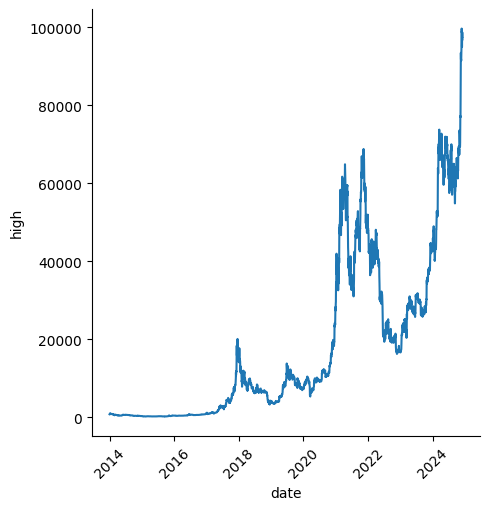

In [16]:
sns.relplot(x="date", y="high", kind="line", data=data)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

<h2> Exercise 2: Predictors/Factors </h2>

<h3> Size </h3>

In [10]:
data["week"] = data["date"].dt.to_period("W")


last_day_mcap = data.groupby("week").last()["market cap"]
log_last_day_mcap = np.log(last_day_mcap)
data = data.merge(log_last_day_mcap, on="week", suffixes=(None, "_MCAP"))

last_day_price = data.groupby("week").last()["close"]
log_last_day_price = np.log(last_day_price)
data = data.merge(log_last_day_price, on="week", suffixes=(None, "_PRC"))

max_day_price = data.groupby("week").max()["close"]
data = data.merge(max_day_price, on="week", suffixes=(None, "_MAXDPRC"))

#print(data.head(15))

/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_11996/2889918100.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["week"] = data["date"].dt.to_period("W")


<h3> Mom </h3>

In [11]:
data["r_1"] = data["close"].diff(6)
data["r_2"] = data["close"].diff(13)
data["r_3"] = data["close"].diff(20)
data["r_4"] = data["close"].diff(27)
data["r_4_1"] = data["r_4"] - data["r_1"]

<h3> Volume </h3>

In [12]:
mean_vol = data.groupby("week")["volume"].mean()
log_mean_vol = np.log(mean_vol)
data = data.merge(log_mean_vol, on="week", suffixes=(None, "PRCVOL"))

std_vol = data.groupby("week")["volume"].std()
log_std_vol = np.log(std_vol)
data = data.merge(log_std_vol, on="week", suffixes=(None, "STDPRCVOL"))


In [13]:
data["diff"] = abs(data["close"].diff(-1)) / data["close"]

#data.groupby("week")["diff"].last = None      was passiert am letzten Tag der Woche => Differenz zur
a = data.groupby("week")["diff"].mean()
data = data.merge(a, on="week", suffixes=(None, "_Step"))
data["DAMIHUD"] = data["diff_Step"] / data["volumePRCVOL"]
data.drop(["diff", "diff_Step"], axis=1, inplace=True)


<h2> Exercise 3 </h2>

In [14]:
data["7d_return"] = data["close"].diff(-6) / data["close"]

<h2> Exercise 4 </h2>

In [9]:
X = data[["open", "close", "high", "low", "volume"]]
y = data["7d_return"]
X = X[:-6]
y = y[:-6]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [41]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
score_mlr = mlr.score(X_test, y_test)
print(score_mlr)

-0.014059699525415637


In [42]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
score_rf = rf.score(X_test, y_test)
print(score_rf)

0.06671354074801805


In [43]:
svm = SVR()
svm.fit(X_train, y_train)
score_svm = svm.score(X_test, y_test)
print(score_svm)

-0.03070268967359091


<h2> Exercise 5 </h2>

In [44]:
predictor_df = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", 
                     "r_1", "r_2", "r_3", "r_4", "r_4_1", 
                     "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return"]]
predictor_df = predictor_df.dropna()

X = predictor_df.drop("7d_return", axis=1)
y = predictor_df["7d_return"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [45]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
score_mlr = mlr.score(X_test, y_test)
print(score_mlr)

0.024711855161719587


In [46]:
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
score_rf = rf.score(X_test, y_test)
print(score_rf)

param_grid = {
    "n_estimators": [100, 200],  
    "max_depth": [None, 15],      
    "min_samples_split": [3, 10],    
}
"""
rf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_mean_absolute_error", cv=4)
rf_cv.fit(X_train, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_

print("Best Parameters:", best_params)
print(best_model.score(X_test, y_test))
"""

0.5705357683017986


'\nrf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_mean_absolute_error", cv=4)\nrf_cv.fit(X_train, y_train)\n\nbest_params = rf_cv.best_params_\nbest_model = rf_cv.best_estimator_\n\nprint("Best Parameters:", best_params)\nprint(best_model.score(X_test, y_test))\n'

In [47]:
svm = SVR()
svm.fit(X_train, y_train)
score_svm = svm.score(X_test, y_test)
print(score_svm)

0.004633712621321395


<h2> Exercise 7 </h2>

In [15]:
p0_buy_and_hold = data["close"].iloc[3287]
pT_buy_and_hold = data["close"].iloc[-1]
return_buy_and_hold = pT_buy_and_hold * (100000 / p0_buy_and_hold)
print(return_buy_and_hold)

580141.8857486378


In [16]:
def buy(cash, bitcoins, price):
    if cash <= 0:
        return cash, bitcoins
    elif cash > 0:
        new_bitcoins = cash / price 
        return 0, (bitcoins + new_bitcoins)
    

def sell(cash, bitcoins, price):
    if bitcoins <= 0:
        return cash, bitcoins
    elif bitcoins > 0:
        return (cash + (price * bitcoins)), 0

In [62]:
predictor_df = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1", "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return", "close"]]
#predictor_df = data[["market cap_MCAP", "close_PRC", "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return", "close"]]
#predictor_df = pd.concat([predictor_df, np.log(data[["close_MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1"]])], axis=1)

sample = predictor_df[:3287]
sample = sample.dropna()
X_sample = sample.drop(["7d_return", "close"], axis=1)
y_sample = sample["7d_return"]

out_of_sample = predictor_df[3287:]
out_of_sample = out_of_sample.dropna()
X_oos = out_of_sample.drop("7d_return", axis=1)
y_oos = out_of_sample["7d_return"]



<h3> Random Forest </h3>

In [91]:
predictor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
"""
predictor.fit(X_sample, y_sample)
print(predictor.score(X_oos.drop("close", axis=1), y_oos))

"""
X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)
predictor.fit(X_sample_train, y_sample_train)
print(predictor.score(X_sample_test, y_sample_test))

y_pred = predictor.predict(X_oos.drop("close", axis=1))
print("AUC-ROC:", roc_auc_score(y_oos > 0, y_pred))
print(predictor.n_features_in_)
tree_depths = [tree.tree_.max_depth for tree in predictor.estimators_]
print(max(tree_depths))

"""
importances = predictor.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_sample.columns, 'Importance': importances})
print(feature_importance_df)
predictor_df.corr()
"""

0.41481203262677124
AUC-ROC: 0.547937427970985
11
10


"\nimportances = predictor.feature_importances_\nfeature_importance_df = pd.DataFrame({'Feature': X_sample.columns, 'Importance': importances})\nprint(feature_importance_df)\npredictor_df.corr()\n"

<h3> Linear Regression </h3>

In [ ]:
predictor = LinearRegression()

predictor.fit(X_sample, y_sample)
print(predictor.score(X_oos.drop("close", axis=1), y_oos))

"""
X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)
predictor.fit(X_sample_train, y_sample_train)
print(predictor.score(X_sample_test, y_sample_test))
"""

0.024877320688555415


<h3> SVM </h3>

In [60]:
predictor = SVR()
predictor.fit(X_sample, y_sample)
print(predictor.score(X_oos.drop("close", axis=1), y_oos))

"""
X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)
predictor.fit(X_sample_train, y_sample_train)
print(predictor.score(X_sample_test, y_sample_test))


param_grid = {
    "kernel": ["rbf", "linear", "sigmoid"],  
    "C": [1, 10],      
    "epsilon": [0.1, 1],
}

rf_cv = GridSearchCV(estimator=predictor, param_grid=param_grid, scoring="neg_mean_absolute_error", cv=2)
rf_cv.fit(X_sample, y_sample)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_

print("Best Parameters:", best_params)
print(best_model.score(X_oos.drop("close", axis=1), y_oos))
"""

-0.3844134415521021


'\nX_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)\npredictor.fit(X_sample_train, y_sample_train)\nprint(predictor.score(X_sample_test, y_sample_test))\n\n\nparam_grid = {\n    "kernel": ["rbf", "linear", "sigmoid"],  \n    "C": [1, 10],      \n    "epsilon": [0.1, 1],\n}\n\nrf_cv = GridSearchCV(estimator=predictor, param_grid=param_grid, scoring="neg_mean_absolute_error", cv=2)\nrf_cv.fit(X_sample, y_sample)\n\nbest_params = rf_cv.best_params_\nbest_model = rf_cv.best_estimator_\n\nprint("Best Parameters:", best_params)\nprint(best_model.score(X_oos.drop("close", axis=1), y_oos))\n'

In [92]:
cash = 100000
bitcoins = 0

for index, row in X_oos.iterrows():
    price = row["close"]
    row.drop("close", inplace=True)
    expected_return = predictor.predict(pd.DataFrame([row], columns=row.index))
    if expected_return > 0:
        cash, bitcoins = buy(cash=cash, bitcoins=bitcoins, price=price) 
    elif expected_return < 0:
        cash, bitcoins = sell(cash=cash, bitcoins=bitcoins, price=price)
    #print("cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * price))

print("cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * data["close"].iloc[-1]))

cash: 0, value in bitcoins: 303175.4401644284
